## Урок 4. Домашнее задание

### 4.1 Домашнее задание начального уровня

Потренируйтесь в программировании на python. Надо будет найти расстояние от каждой точки из массива $X$ до центра кластера, а потом просуммировать эти расстояния. Это будет реализацией библиотечной функции `sklearn.metrics.pairwise.euclidean_distances` из первого урока.  В итоге у Вас должно получиться число чуть более $16$ - это и будет расстояние.
$$
\sum_{i=1}^{k} \mid x_i - c \mid
$$

где для одного обучающего примера x, состоящего из двух координат:
$$
\mid x - c \mid = (x_1-c_1)^2 + (x_2-c_2)^2
$$

**Примечание** Как вы уже знаете из урока про линейную регрессию, в этой формуле должен быть квадратный корень, но для скорости работы мы опускаем его.

**Подсказка** Средствами библиотеки numpy реализуйте формулу нахождения суммы внутрикластерных расстояний

In [2]:
import numpy as np

clust = np.array([
 [-0.5972191612445694, -0.5919098916910581],
 [-1.5838020751869848, 0.4743393635868491],
 [-1.892642118066139, -1.2770390481464395],
 [-1.021761443519372, -0.38446059106320013],
 [-0.628271339507516, -2.308149346281125],
 [-0.7180915776856387, 1.1805550909358404],
 [-1.543143767548152, -1.4163791359687334],
 [0.022103701018375554, -1.1279478858865397],
 [-0.7776518874305778, -0.4157532453316538],
 [-1.2073577296008344, -1.1308523658604184]
])

centroid = np.array([-0.9774245525274352, -0.032635425821084516])

# -- ВАШ КОД ТУТ --
squared_distances = np.sum((clust - centroid)**2)
print("Сумма квадратов расстояний до центра:", squared_distances)


Сумма квадратов расстояний до центра: 16.312116964385638


### 4.2 Домашнее задание начального уровня  

Обучите алгоритм k-средних для количества кластеров $n=3$ на том же датасете, который содержится в файле `data/clustering.pkl`. Визуализируйте результат:

C:\Users\Admin\AppData\Local\Temp\ipykernel_17636\749798057.py:10: DeprecationWarning: numpy.core._multiarray_umath is deprecated and has been renamed to numpy._core._multiarray_umath. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core._multiarray_umath._reconstruct.
  data_clustering = pickle.load(f)


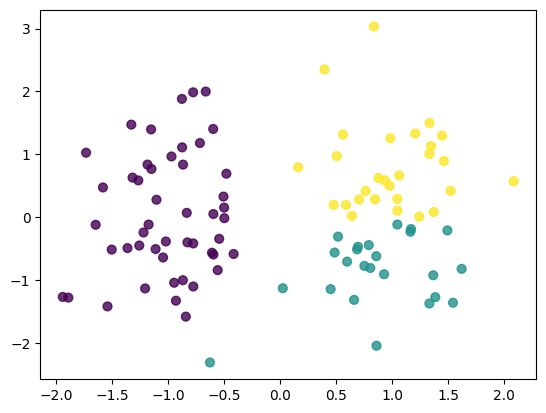

In [3]:
# -- ВАШ КОД ТУТ --
import pickle
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
%matplotlib inline

# данные получены с помощью функции make_classification
with open('data/clustering.pkl', 'rb') as f:
    data_clustering = pickle.load(f)
    
X = np.array(data_clustering['X'])
Y = np.array(data_clustering['Y'])
    
kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_model.fit(X)

plt.scatter(X[:, 0], X[:, 1], s=40, c=kmeans_model.labels_, marker='o', alpha=0.8, label='data')
plt.show()

### 4.3 Домашнее задание высокого уровня

Мы узнали про эвристику, улучшающую алгоритм: запустить несколько раз алгоритм, запомнить, куда попали центроиды при каждом запуске, а потом усреднить координаты за все несколько запуска.

Попробуйте применить эту эвристику на практике:

* используйте 10 запусков алгоритма $k$-средних для $k=2$ с параметрами
<pre>
kmeans_model = KMeans(n_clusters=2, n_init=1, random_state=None, algorithm='full', max_iter=2)
</pre>
* в каждом запуске сохраняйте координаты центроидов общий массив $c$. См. `cluster_centers_ : array, [n_clusters, n_features]`
* визуализируйте координаты точек из $c$ на фоне исходного множества точек

Результат будет примерно такой:
![several_init_knn](https://248006.selcdn.ru/public/DS.%20Block%202.%20M7/several_init_knn.png)

In [9]:
# -- ВАШ КОД ТУТ --
# Будем собирать все центры сюда
all_centers = []

for i in range(10):
    kmeans_model = KMeans(n_clusters=2, n_init=1, random_state=None, max_iter=2)
    kmeans_model.fit(X)
    
    #Сохраняем центроиды
    centers = kmeans_model.cluster_centers_
    all_centers.append(centers)
    
# Преобразуем список в numpy-массив
all_centers = np.array(all_centers)
print(all_centers.shape)
all_centers

(10, 2, 2)


array([[[ 0.80780043, -0.21272684],
        [-0.91039577,  0.31333943]],

       [[-0.98640477,  0.35170739],
        [ 0.71472107, -0.19516   ]],

       [[ 0.95917947,  0.07757361],
        [-0.99782309, -0.01028211]],

       [[ 0.80491291,  0.32249851],
        [-0.94435817, -0.30353237]],

       [[ 0.97792098,  0.10168404],
        [-0.97742455, -0.03263543]],

       [[-0.84234396,  1.18726576],
        [ 0.23790242, -0.2906079 ]],

       [[ 0.97792098,  0.10168404],
        [-0.97742455, -0.03263543]],

       [[-0.94785413,  0.05178137],
        [ 0.98704862,  0.01656288]],

       [[ 0.97792098,  0.10168404],
        [-0.97742455, -0.03263543]],

       [[-0.91915055,  0.15652454],
        [ 0.95717346, -0.09245553]]])

In [10]:
# Объединяем все центры в одну плоскость
flat_centers = all_centers.reshape(-1, 2)  # shape = (20, 2)

# Вычисляем средние координаты всех "наблюдаемых" центров
avg_centers = np.mean(flat_centers, axis=0)

flat_centers

array([[ 0.80780043, -0.21272684],
       [-0.91039577,  0.31333943],
       [-0.98640477,  0.35170739],
       [ 0.71472107, -0.19516   ],
       [ 0.95917947,  0.07757361],
       [-0.99782309, -0.01028211],
       [ 0.80491291,  0.32249851],
       [-0.94435817, -0.30353237],
       [ 0.97792098,  0.10168404],
       [-0.97742455, -0.03263543],
       [-0.84234396,  1.18726576],
       [ 0.23790242, -0.2906079 ],
       [ 0.97792098,  0.10168404],
       [-0.97742455, -0.03263543],
       [-0.94785413,  0.05178137],
       [ 0.98704862,  0.01656288],
       [ 0.97792098,  0.10168404],
       [-0.97742455, -0.03263543],
       [-0.91915055,  0.15652454],
       [ 0.95717346, -0.09245553]])

Мы выяснили, что один из недостатков алгоритма k-средних состоит в том, что количество кластеров надо задать до тренировки модели, но как же определить, сколько будет кластеров в данных? Для этой задачи существует эффективный алгоритм, о котором мы поговорим в следующем уроке.

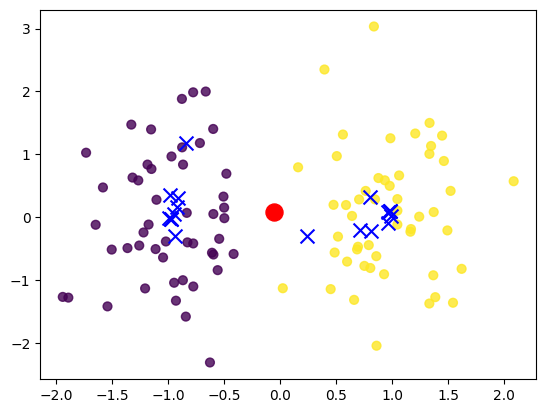

In [12]:
plt.scatter(X[:, 0], X[:, 1], s=40, c=kmeans_model.labels_, marker='o', alpha=0.8, label='data')
# Отображаем все центры, полученные в 10 запусках
plt.scatter(flat_centers[:, 0], flat_centers[:, 1], c='blue', marker='x', s=100, label='All trial centers')

# Отображаем средний центр (или два центра, если будем усреднять аккуратно)
plt.scatter(avg_centers[0], avg_centers[1], c='red', marker='o', s=150, label='Averaged center')
plt.show()